In [4]:
import numpy as np

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense




In [5]:
from tensorflow.keras.activations import relu, linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam


In [69]:

%matplotlib widget

In [8]:

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from public_tests_a1 import *

tf.keras.backend.set_floatx('float64')
from assigment_utils import *

tf.autograph.set_verbosity(0)


In [20]:
X,y,x_ideal,y_ideal = gen_data(18, 2, 0.7)
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(18,) (18,)
(12,) (12,)
(6,) (6,)


In [31]:
x_ideal

(18,)

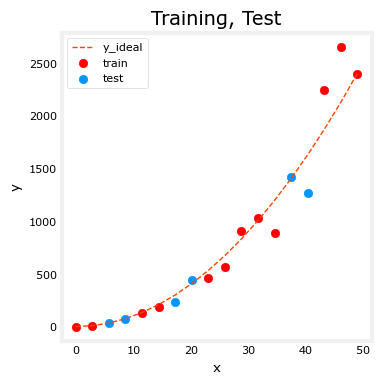

In [28]:
fig, ax = plt.subplots(1,1, figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label= "y_ideal", lw = 1)
ax.set_title("Training, Test", fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red", label = "train")
ax.scatter(X_test, y_test, color = dlc['dlblue'], label = "test")
ax.legend(loc= 'upper left')




In [32]:
def eval_mse(y, yhat):
    m = (len(y))
    err = 0.0
    for i in range(m):
        err += ((yhat[i] - y[i] ) **2 )
    err = err / (2*m)
    return (err)

In [33]:
y_hat = np.array([2.4,  4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)

test_eval_mse(eval_mse)

 All tests passed.


In [36]:
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train, y_train)

yhat = lmodel.predict(X_train)
err_train = lmodel.mse(y_train, yhat)

yhat = lmodel.predict(X_test)
err_test = lmodel.mse(y_test, yhat)

In [37]:
print(f"train err:, {err_train}, test err: , {err_test}")

train err:, 58.00756057277448, test err: , 171215.01170007995


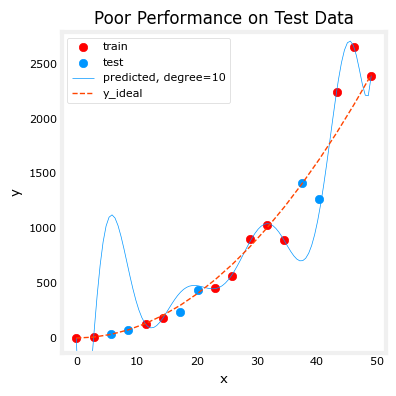

In [42]:
x = np.linspace(0, int(X.max()),100)
y_pred = lmodel.predict(x).reshape(-1,1)
# y_pred.shape

plt_train_test(X_train, y_train, X_test, y_test, x, y_pred, x_ideal, y_ideal, degree)

In [50]:
X,y, x_ideal, y_ideal = gen_data(40, 5, 0.7)
print(X.shape, y.shape)

X_train, X_, y_train, y_ = train_test_split(X,y, test_size=0.4, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_, test_size=0.5, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

(40,) (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


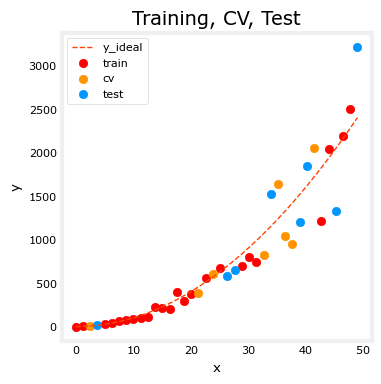

In [51]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, CV, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_cv, y_cv,       color = dlc["dlorange"], label="cv")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

In [56]:
max_degree = 9 
err_train = np.zeros(max_degree)    
err_cv = np.zeros(max_degree)      
x = np.linspace(0,int(X.max()),100)  
y_pred = np.zeros((100,max_degree))  #columns are lines to plot

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv, yhat)
    y_pred[:,degree] = lmodel.predict(x)
    
optimal_degree = np.argmin(err_cv)+1



In [57]:
optimal_degree

2

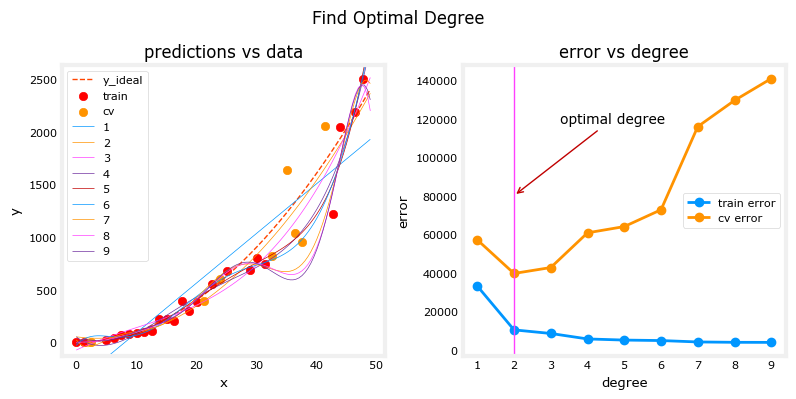

In [58]:
plt.close("all")
plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal, 
                   err_train, err_cv, optimal_degree, max_degree)

In [64]:
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)    
err_cv = np.zeros(num_steps)       
x = np.linspace(0,int(X.max()),100) 
y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_= lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)
    y_pred[:,i] = lmodel.predict(x)
    
optimal_reg_idx = np.argmin(err_cv) 

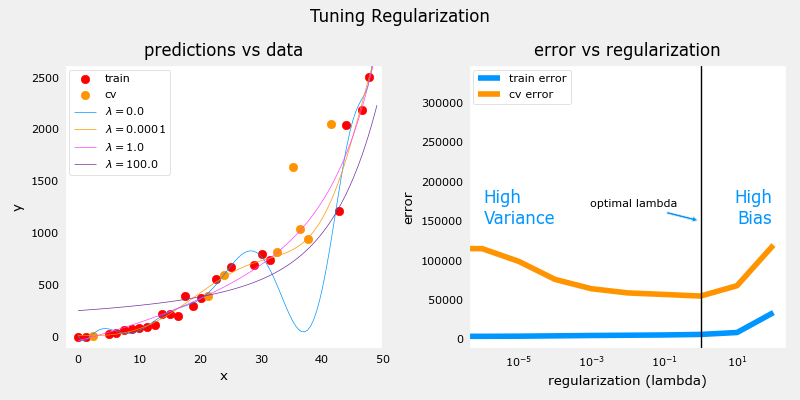

In [74]:
# plt.close("all")
plt_tune_regularization(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range)

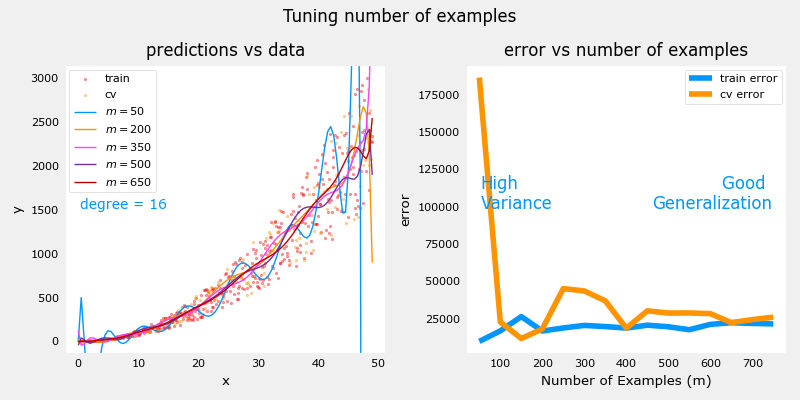

In [75]:
X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range,degree = tune_m()
plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree)

In [77]:
# Generate and split data set
X, y, centers, classes, std = gen_blobs()

#  split the data. Large CV population for demonstration
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.20, random_state=1)
print("X_train.shape:", X_train.shape, "X_cv.shape:", X_cv.shape, "X_test.shape:", X_test.shape)

X_train.shape: (400, 2) X_cv.shape: (320, 2) X_test.shape: (80, 2)


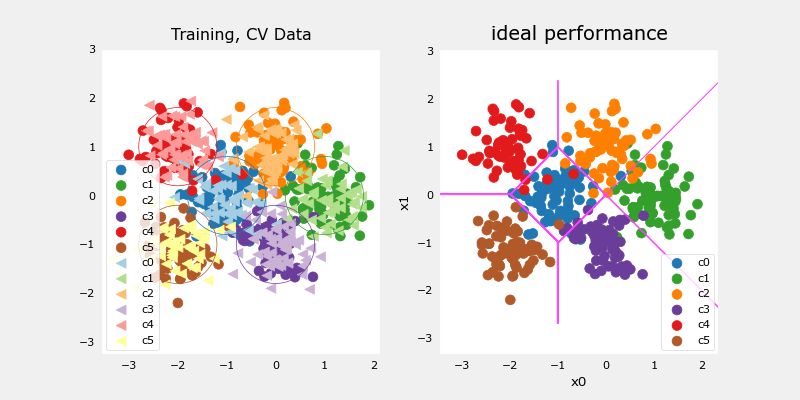

In [78]:
plt_train_eq_dist(X_train, y_train,classes, X_cv, y_cv, centers, std)

In [81]:
def eval_cat_err(y,yhat):

    m = len(y)
    incorrect = 0
    cerr = 0
    for i in range(m):
        if yhat[i] != y[i]:
            incorrect += 1
    cerr = 1/m * (incorrect)

        
    return (cerr)

In [82]:
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333" )
y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250" )

# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST
# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250
 All tests passed.
 All tests passed.


In [86]:
# import logging
# logging.getLogger("tensorflow").setLevel(logging.ERROR)

tf.random.set_seed(1234)
model = Sequential([

    Dense(120 , activation='relu'),
    Dense(40, activation='relu'),
    Dense(6, activation='linear')
], name = "Complex"
)

model.compile(
    loss = SparseCategoricalCrossentropy(from_logits=True),
    optimizer = Adam(learning_rate =0.01)

)



In [87]:
model.fit(
    X_train, y_train,
    epochs = 1000
)

Epoch 1/1000
13/13 [==============================] - 1s 2ms/step - loss: 1.0803
Epoch 2/1000
13/13 [==============================] - 0s 2ms/step - loss: 0.4182
Epoch 3/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.3177
Epoch 4/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.2858
Epoch 5/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.2788
Epoch 6/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.2944
Epoch 7/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.2488
Epoch 8/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.2329
Epoch 9/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.2372
Epoch 10/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.1984
Epoch 11/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.2149
Epoch 12/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.2068
Epoch 13/1000
13/13 [====

1082/1082 [==============================] - 1s 835us/step


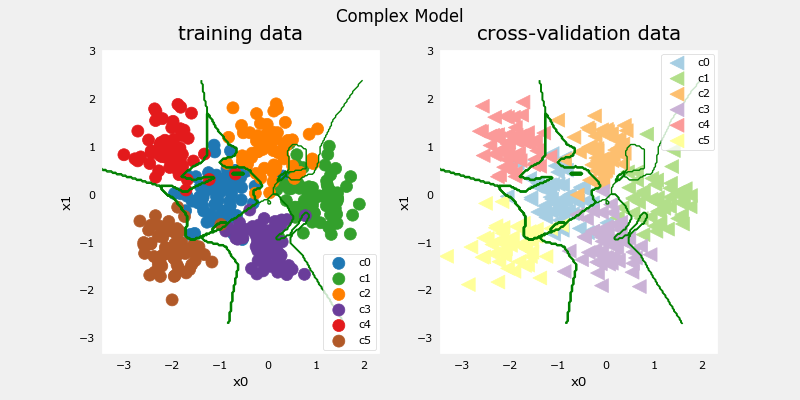

In [88]:
model_predict = lambda Xl: np.argmax(tf.nn.softmax(model.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict,X_train,y_train, classes, X_cv, y_cv, suptitle="Complex Model")

In [89]:
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")

10/10 [==============================] - 0s 777us/step
categorization error, training, complex model: 0.010
categorization error, cv,       complex model: 0.109


In [91]:
tf.random.set_seed(1234)
model_s = Sequential([
    Dense(6, activation = "relu"),
    Dense(6, activation = "linear")


], name = "Simple"
)
model_s.compile(
    loss = SparseCategoricalCrossentropy(from_logits=True),
    optimizer = Adam(learning_rate = 0.01)
)


In [92]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

model_s.fit(
    X_train, y_train,
    epochs = 1000
)

Epoch 1/1000
13/13 [==============================] - 0s 1ms/step - loss: 1.6694
Epoch 2/1000
13/13 [==============================] - 0s 833us/step - loss: 1.3942
Epoch 3/1000
13/13 [==============================] - 0s 1000us/step - loss: 1.1634
Epoch 4/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.9316
Epoch 5/1000
13/13 [==============================] - 0s 916us/step - loss: 0.7392
Epoch 6/1000
13/13 [==============================] - 0s 917us/step - loss: 0.5960
Epoch 7/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.5061
Epoch 8/1000
13/13 [==============================] - 0s 917us/step - loss: 0.4424
Epoch 9/1000
13/13 [==============================] - 0s 917us/step - loss: 0.4008
Epoch 10/1000
13/13 [==============================] - 0s 961us/step - loss: 0.3712
Epoch 11/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.3479
Epoch 12/1000
13/13 [==============================] - 0s 917us/step - loss: 0.3330
Epoch 13

In [93]:
# BEGIN UNIT TEST
model_s.summary()

model_s_test(model_s, classes, X_train.shape[1])
# END UNIT TEST

Model: "Simple"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 6)                 18        
                                                                 
 dense_4 (Dense)             (None, 6)                 42        
                                                                 
Total params: 60
Trainable params: 60
Non-trainable params: 0
_________________________________________________________________
All tests passed!


1082/1082 [==============================] - 1s 593us/step


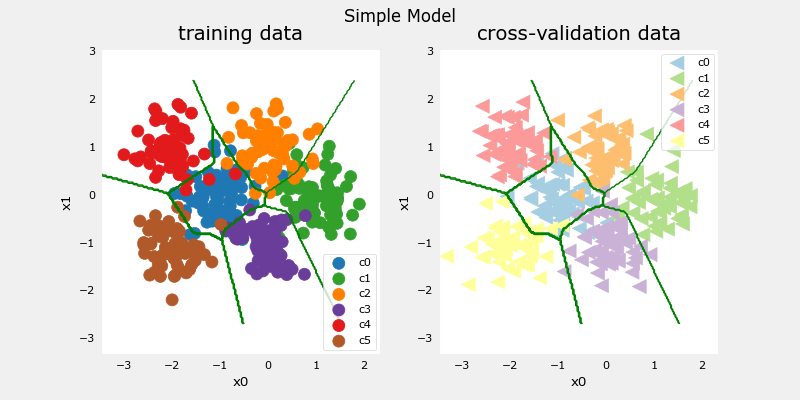

In [94]:
#make a model for plotting routines to call
model_predict_s = lambda Xl: np.argmax(tf.nn.softmax(model_s.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict_s,X_train,y_train, classes, X_cv, y_cv, suptitle="Simple Model")

In [95]:
training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f"categorization error, training, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

10/10 [==============================] - 0s 1ms/step
categorization error, training, simple model, 0.072, complex model: 0.010
categorization error, cv,       simple model, 0.066, complex model: 0.109


In [104]:
tf.random.set_seed(1234)
model_r = Sequential([ 

    Dense(120, activation = "relu", kernel_regularizer= tf.keras.regularizers.l2(0.1), name = "L1"),
    Dense(40, activation = "relu", kernel_regularizer = tf.keras.regularizers.l2(0.1), name = "L2"),
    Dense(6, activation = "linear")
    
], name ="Reg"
)

model_r.compile(
    loss = SparseCategoricalCrossentropy(from_logits=True), 
    optimizer = Adam(learning_rate = 0.01)
)



1082/1082 [==============================] - 1s 637us/step


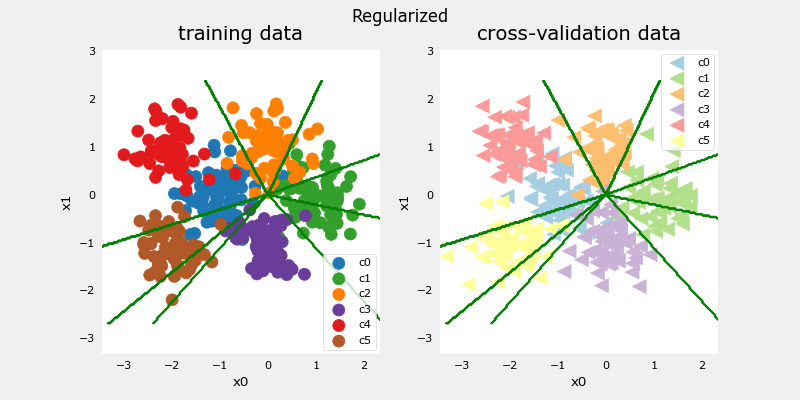

In [101]:
#make a model for plotting routines to call
model_predict_r = lambda Xl: np.argmax(tf.nn.softmax(model_r.predict(Xl)).numpy(),axis=1)
 
plt_nn(model_predict_r, X_train,y_train, classes, X_cv, y_cv, suptitle="Regularized")

In [102]:
# BEGIN UNIT TEST
model_r.summary()

model_r_test(model_r, classes, X_train.shape[1]) 

Model: "Reg"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 L1 (Dense)                  (None, 120)               360       
                                                                 
 L2 (Dense)                  (None, 40)                4840      
                                                                 
 dense_5 (Dense)             (None, 6)                 246       
                                                                 
Total params: 5,446
Trainable params: 5,446
Non-trainable params: 0
_________________________________________________________________
ddd
All tests passed!


In [103]:
training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
test_cerr_reg = eval_cat_err(y_test, model_predict_r(X_test))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

3/3 [==============================] - 0s 1ms/step
categorization error, training, regularized: 0.598, simple model, 0.072, complex model: 0.010
categorization error, cv,       regularized: 0.569, simple model, 0.066, complex model: 0.109


In [ ]:
tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models=[None] * len(lambdas)
for i in range(len(lambdas)):
    lambda_ = lambdas[i]
    models[i] =  Sequential(
        [
            Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(classes, activation = 'linear')
        ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.01),
    )

    models[i].fit(
        X_train,y_train,
        epochs=1000
    )
    print(f"Finished lambda = {lambda_}")
